In [1]:
# ================================================
# Notebook 3: Handwriting Recognition
# Purpose: Convert preprocessed images into editable text
# Model Used: TrOCR (Best for messy handwriting)
# ================================================

print("🔤 Notebook 3: Handwriting Recognition Started")
print("Using Microsoft TrOCR model for handwritten text recognition")

🔤 Notebook 3: Handwriting Recognition Started
Using Microsoft TrOCR model for handwritten text recognition


In [2]:
# Cell 2: Imports
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("✅ Libraries imported")
print(f"GPU Available: {torch.cuda.is_available()}")

c:\Users\Avilasha\Desktop\handwriting-ocr\cuda_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported
GPU Available: True


In [3]:
# Load the TrOCR Model
# Cell 3: Load TrOCR Model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"✅ TrOCR Model loaded successfully on → {device}")

Loading weights: 100%|██████████| 478/478 [00:00<00:00, 4343.64it/s]
VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ TrOCR Model loaded successfully on → cuda


In [4]:
# Cell 4: Handwriting Recognition Function (Clean Version)

from utils import preprocess_handwriting   # ← Import from utils.py

def recognize_text(image_path, preprocess=True):
    """
    Recognize handwritten text from an image using TrOCR
    """
    # Load original image for display
    if isinstance(image_path, str):
        pil_image = Image.open(image_path).convert("RGB")
        original_cv = cv2.imread(image_path)
    else:
        pil_image = image_path
        original_cv = cv2.cvtColor(np.array(image_path), cv2.COLOR_RGB2BGR)
    
    # Preprocessing
    if preprocess:
        print("🛠️ Applying preprocessing...")
        processed_pil, _ = preprocess_handwriting(image_path, show_steps=False)
        final_image = processed_pil
    else:
        final_image = pil_image
    
    # Show original image
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(original_cv, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    plt.show()
    
    # Run TrOCR
    pixel_values = processor(images=final_image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)
    
    print("🤖 Recognizing text with TrOCR... (this may take 5-15 seconds)")
    
    generated_ids = model.generate(pixel_values, max_new_tokens=500)
    recognized_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    
    print("\n" + "="*70)
    print("✅ RECOGNIZED TEXT:")
    print("="*70)
    print(recognized_text)
    print("="*70)
    
    return recognized_text

🛠️ Applying preprocessing...


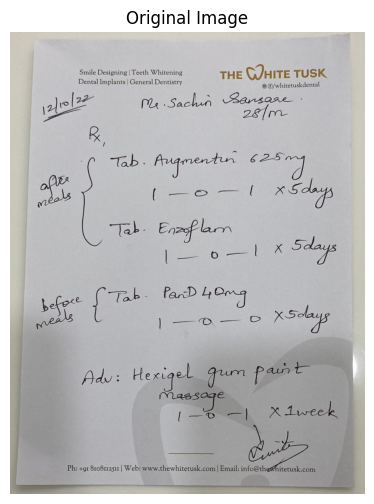

🤖 Recognizing text with TrOCR... (this may take 5-15 seconds)

✅ RECOGNIZED TEXT:
A 72-

✅ Text also saved to 'recognized_text.txt'


In [5]:
# Test on Single Image
# Cell 5: Test Recognition on One Image
# =====================================


# Change this path to your actual image
test_image_path = r"C:\Users\Avilasha\Desktop\handwriting-ocr\input_images\1_3xUyINxRtDf2qowd-kkGQA.jpg"

recognized_text = recognize_text(test_image_path, preprocess=True)

# Save the text to a file
with open("recognized_text.txt", "w", encoding="utf-8") as f:
    f.write(recognized_text)

print("\n✅ Text also saved to 'recognized_text.txt'")